In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


**EDA**

In [3]:
df=pd.read_csv("/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [5]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [6]:
# List of categorical columns to analyze
categorical_columns = ["Category", "Region", "Weather Condition", "Seasonality"]

# Loop through each column and print frequency counts
for col in categorical_columns:
    print(f"Frequency counts for {col}:")
    print(df[col].value_counts())
    print("=" * 50)


Frequency counts for Category:
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64
Frequency counts for Region:
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64
Frequency counts for Weather Condition:
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64
Frequency counts for Seasonality:
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64


In [7]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


**Data Visualization**

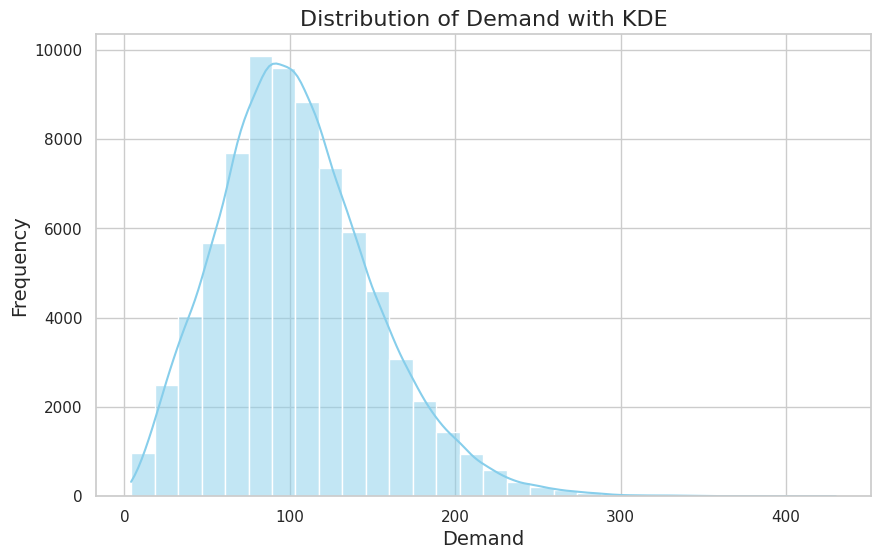

In [8]:
# Set style
sns.set(style="whitegrid")

# Plot histogram with KDE overlay
plt.figure(figsize=(10,6))
sns.histplot(df["Demand"], bins=30, kde=True, color="skyblue")

# Add labels and title
plt.title("Distribution of Demand with KDE", fontsize=16)
plt.xlabel("Demand", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()


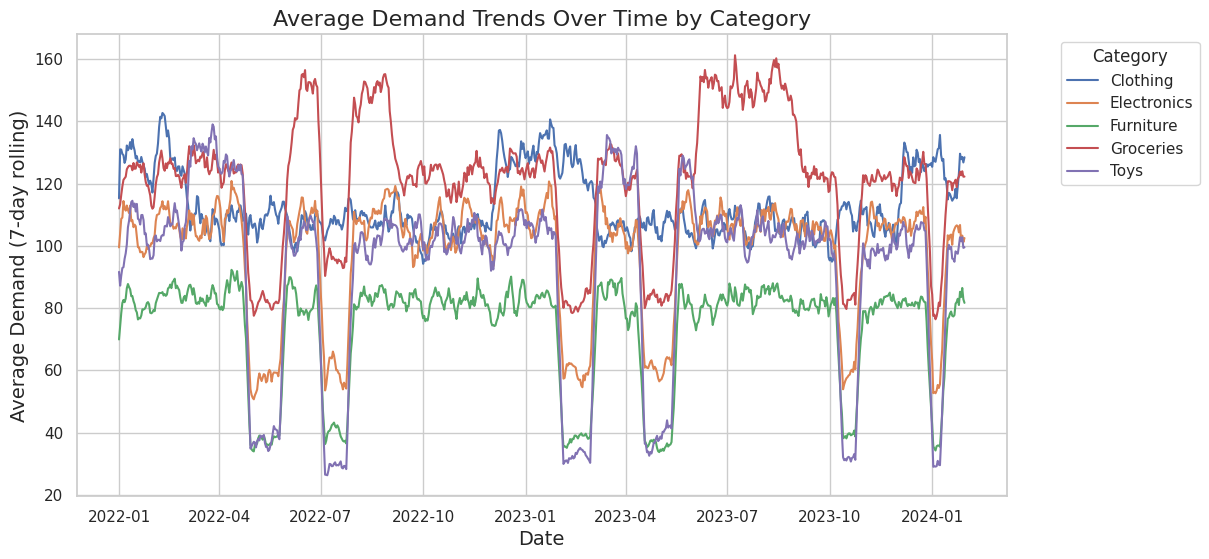

In [9]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Group by Category and Date, calculate average demand
df_grouped = df.groupby(["Date", "Category"])["Demand"].mean().reset_index()

# Optionally add a rolling average (7-day window) for smoother trend
df_grouped["Rolling_Avg"] = df_grouped.groupby("Category")["Demand"].transform(lambda x: x.rolling(7, min_periods=1).mean())

# Set style
sns.set(style="whitegrid")

# Plot average demand trends over time by category
plt.figure(figsize=(12,6))
sns.lineplot(data=df_grouped, x="Date", y="Rolling_Avg", hue="Category")

# Add labels and title
plt.title("Average Demand Trends Over Time by Category", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Average Demand (7-day rolling)", fontsize=14)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


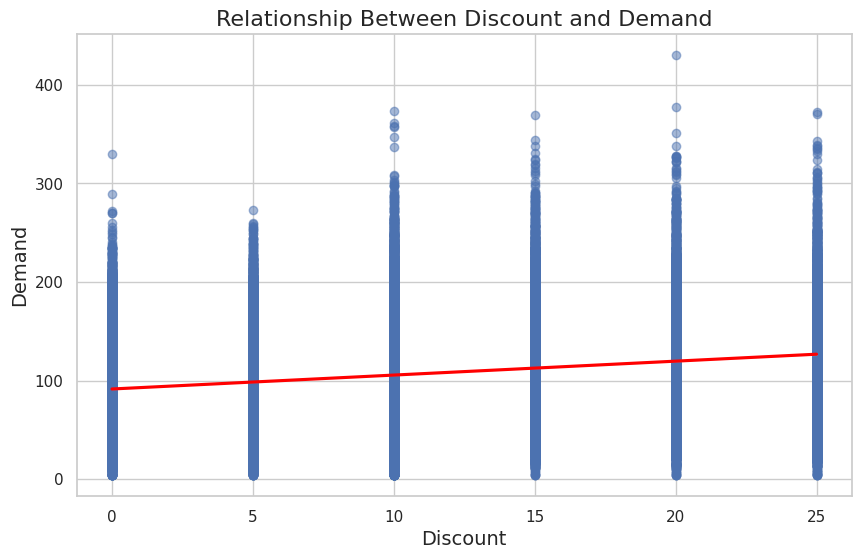

In [10]:
# Set style
sns.set(style="whitegrid")

# Scatter plot with regression line
plt.figure(figsize=(10,6))
sns.regplot(data=df, x="Discount", y="Demand", scatter_kws={"alpha":0.5}, line_kws={"color":"red"})

# Add labels and title
plt.title("Relationship Between Discount and Demand", fontsize=16)
plt.xlabel("Discount", fontsize=14)
plt.ylabel("Demand", fontsize=14)

plt.show()


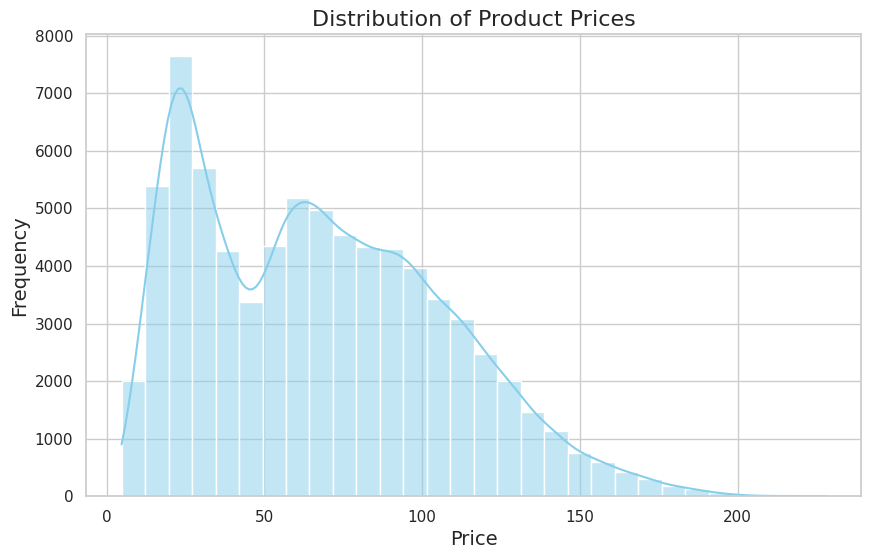

In [11]:
# Set style
sns.set(style="whitegrid")

# Plot histogram of Price
plt.figure(figsize=(10,6))
sns.histplot(df["Price"], bins=30, kde=True, color="skyblue")

# Add labels and title
plt.title("Distribution of Product Prices", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()


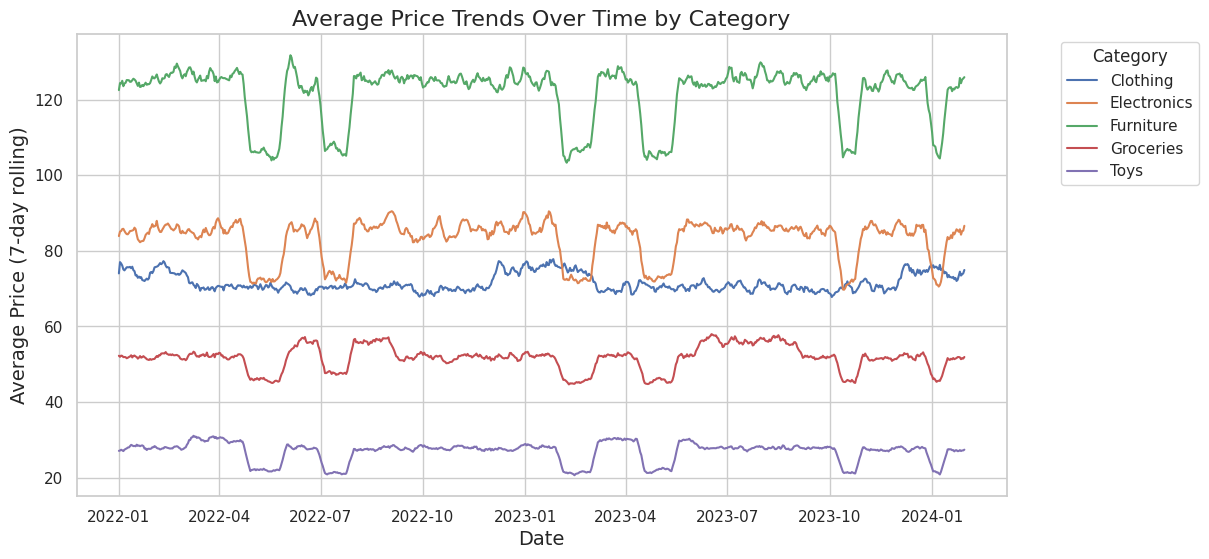

In [12]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Group by Category and Date, calculate average price
df_grouped = df.groupby(["Date", "Category"])["Price"].mean().reset_index()

# Optionally add a rolling average (7-day window) for smoother trend
df_grouped["Rolling_Avg"] = df_grouped.groupby("Category")["Price"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

# Set style
sns.set(style="whitegrid")

# Plot average price trends over time by category
plt.figure(figsize=(12,6))
sns.lineplot(data=df_grouped, x="Date", y="Rolling_Avg", hue="Category")

# Add labels and title
plt.title("Average Price Trends Over Time by Category", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Average Price (7-day rolling)", fontsize=14)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


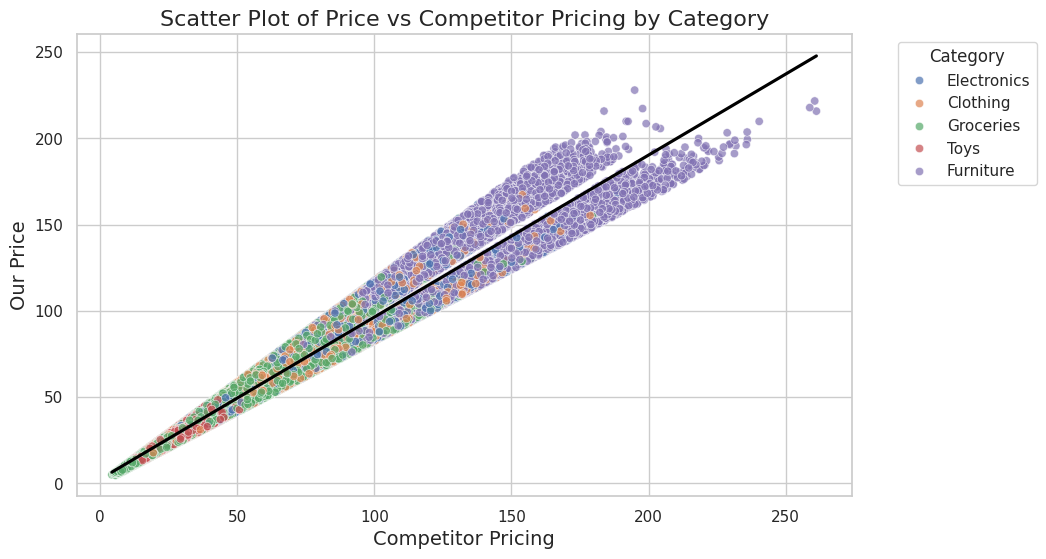

In [13]:
# Set style
sns.set(style="whitegrid")

# Scatter plot comparing Price vs Competitor Pricing with categories
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Competitor Pricing", y="Price", hue="Category", alpha=0.7)

# Add regression line for overall trend
sns.regplot(data=df, x="Competitor Pricing", y="Price", scatter=False, color="black")

# Add labels and title
plt.title("Scatter Plot of Price vs Competitor Pricing by Category", fontsize=16)
plt.xlabel("Competitor Pricing", fontsize=14)
plt.ylabel("Our Price", fontsize=14)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


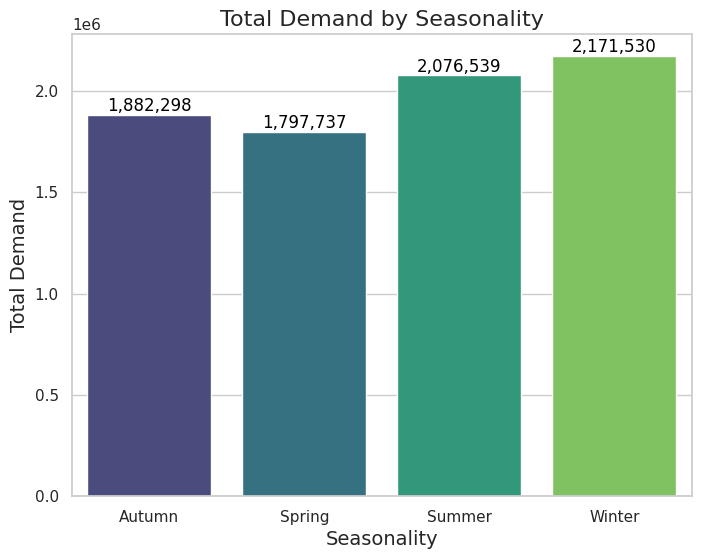

In [14]:
# Group by Seasonality and calculate total demand
season_demand = df.groupby("Seasonality")["Demand"].sum().reset_index()

# Set style
sns.set(style="whitegrid")

# Plot bar chart
plt.figure(figsize=(8,6))
ax = sns.barplot(data=season_demand, x="Seasonality", y="Demand", palette="viridis")

# Add labels and title
plt.title("Total Demand by Seasonality", fontsize=16)
plt.xlabel("Seasonality", fontsize=14)
plt.ylabel("Total Demand", fontsize=14)

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color="black")

plt.show()


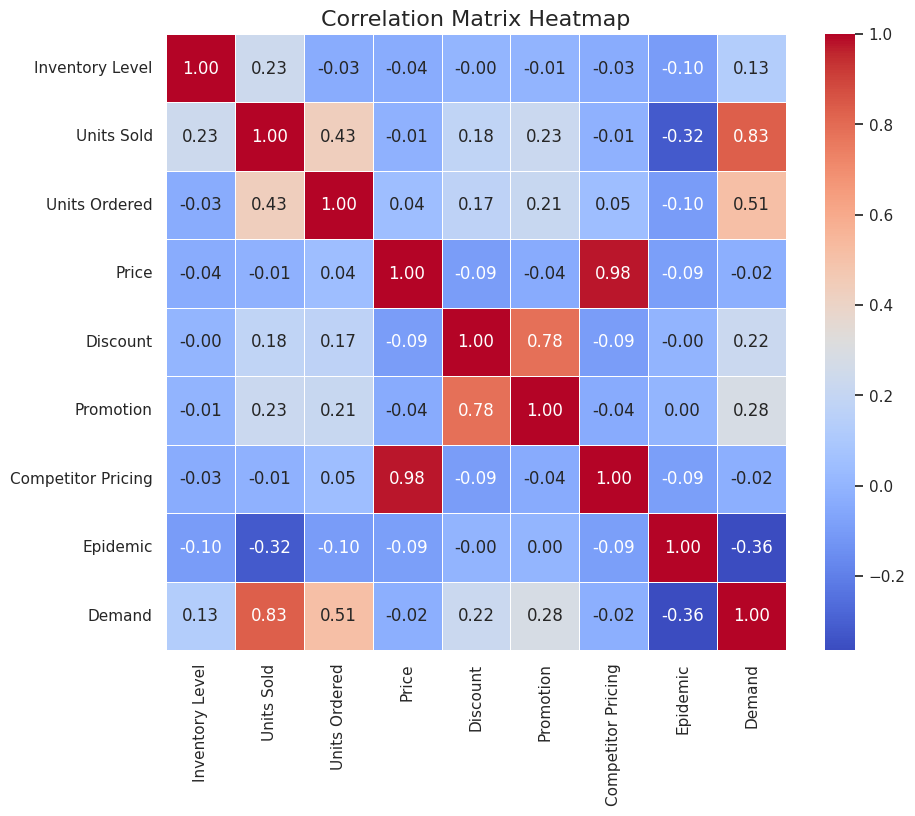

In [15]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
corr = numeric_df.corr()

# Set style
sns.set(style="whitegrid")

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add title
plt.title("Correlation Matrix Heatmap", fontsize=16)

plt.show()
